### Volatility Forecasting Framework

Let $P_t$ denote the asset price at time $t$. We define log-returns as:

$$r_t = \log\left(\frac{P_t}{P_{t-1}}\right)$$

We construct a proxy for realized volatility using 5-day realized variance:

$$\widehat{\sigma}^2_{t,5d} = \frac{1}{5} \sum_{i=0}^{4} r_{t-i}^2$$

To stabilize the distribution and reduce skewness, we model the logarithm of realized variance:

$$y_t = \log\left(\widehat{\sigma}^2_{t,5d} + \varepsilon\right)$$

where $\varepsilon$ is a small constant to avoid numerical issues.

We compare three forecasting approaches:
- **Naive**: persistence-based forecast
- **HAR**: Heterogeneous Autoregressive model
- **HAR+XGB**: machine learning enhancement of HAR residuals

In [1]:
from src.data import *
from src.features import *
from src.walk_forward_splits import *
from src.models import *
from src.plots import *
from src.backtest import *
from src.evaluation import *
from src.strategy import *

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

### Data Loading and Volatility Target Construction

Here we define out main variables and load our data set.

We retrieve daily adjusted closing prices for the main asset and a set of cross-assets. All series are aligned on a common date index to ensure consistency across features.

Also we construct the proxy for realized volatility using 5-day realized variance.

In [2]:
#variables
MAIN_ASSET  = "^AEX"
CROSS_ASSETS = ['^STOXX50E', '^GDAXI', 'VGK']
HAR_WINDOW = 252
start_date="2018-01-01"
end_date="2026-01-01"

In [3]:
price_df, cross_prices, target_5d = load_data(MAIN_ASSET, CROSS_ASSETS, start_date, end_date)

### HAR modelling

The HAR forecast is modeled using walk forward splits with an initial train ratio set. Here, the HAR model uses daily, weekly and monthly realized volatility components to forecast the volatility of the next period.

In [4]:
train_ratio = 0.25

splits = walk_forward_splits(target_5d, train_ratio)

#Train HAR model
y_true, y_har, naive_log, residuals = har_walk_forward_forecast(target_5d, HAR_WINDOW, splits)

#Evaluate HAR model
metrics = evaluate_forecast(y_true, y_har, naive_log, model_name="HAR", bench_name="Naive")

In [5]:
forecast_metrics(metrics)

,RMSE,MAE,QLIKE
Naive,0.5328,0.3311,0.1769
HAR,0.5202,0.3479,0.1644
Improvement,2.37%,-5.08%,7.06%


We observe that this model provides modest improvement over the naive baseline in RMSE and QLIKE, and performs worse in MAE.

### Feature Engineering

We construct features based on historical volatility dynamics and cross-asset information. These features are used to predict future realized volatility.

In [6]:
#Feature engineering
feature_df = feature_engineering(target_5d, MAIN_ASSET, price_df, cross_prices)
feature_df = feature_df.loc[residuals.index].copy()

feature_df["har_residual"] = residuals

The following dataframe contains our features and our HAR model residual, used for XGBoost modelling.

In [7]:
print(feature_df.columns)

Index(['^AEX_d', '^AEX_ret_5', '^AEX_abs_ret_1', '^AEX_abs_ret_5',
       '^AEX_neg_ret_1', '^AEX_neg_ret_sq_1', '^AEX_downside_5',
       '^AEX_upside_5', '^AEX_vol_std_5', '^AEX_vol_std_22', 'VGK_ret_1',
       'VGK_absret_5', '^GDAXI_ret_1', '^GDAXI_absret_5', '^STOXX50E_ret_1',
       '^STOXX50E_absret_5', 'har_residual'],
      dtype='object')


### Feature Selection

We select features based on their correlation with the target variable. Only features with sufficient predictive signal are retained for modeling. We rely on both automated and manual selection of features

In [8]:
train_cutoff = int(len(feature_df) * 0.8)

#(manually) selected features
selected_features = {
    MAIN_ASSET: [
        f"{MAIN_ASSET}_ret_5",
        f"{MAIN_ASSET}_abs_ret_1",
        f"{MAIN_ASSET}_abs_ret_5",
        f"{MAIN_ASSET}_neg_ret_1",
        f"{MAIN_ASSET}_neg_ret_sq_1",
        f"{MAIN_ASSET}_upside_5",
        f"{MAIN_ASSET}_vol_std_5",
        f"{MAIN_ASSET}_vol_std_22",
    ]
}

for asset in CROSS_ASSETS:
    selected_features[asset] = [f"{asset}_ret_1", f"{asset}_sqret_5"]

#keep only features that are in dataset
selected_features = {
    asset: [col for col in feats if col in feature_df.columns]
    for asset, feats in selected_features.items()
}

#correlation filtering on train only
selected_features = target_feature_correlations(feature_df.iloc[:train_cutoff], selected_features, target_col="har_residual")

^AEX


,corr
^AEX_vol_std_5,0.211044
^AEX_abs_ret_1,0.095498
^AEX_ret_5,-0.150893


^STOXX50E


,corr


^GDAXI


,corr


VGK


,corr
VGK_ret_1,-0.092534


In [9]:
print(selected_features)

{'^AEX': ['^AEX_vol_std_5', '^AEX_abs_ret_1', '^AEX_ret_5'], '^STOXX50E': [], '^GDAXI': [], 'VGK': ['VGK_ret_1']}


The feature correlation matrix shows no significant multicollinearity, although XGB can handle correlated inputs.

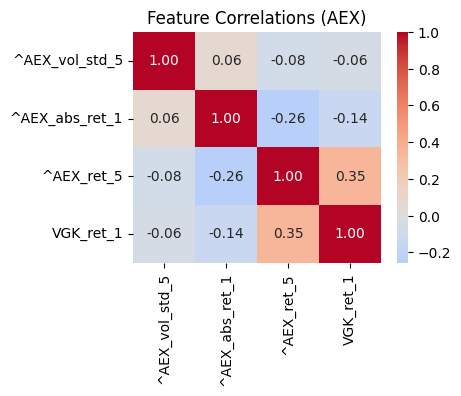

In [10]:
plot_correlations(feature_df, selected_features)

### Hyperparameter tuning

Here we tune the hyperparameters of our model using Optuna. We chose to apply 25 trials and print the best parameters for the XGBoost model.

In [11]:
best_params = xgb_tuning(feature_df, selected_features, train_ratio, train_cutoff=train_cutoff, n_trials=25)
print("Best parameters:", best_params)

Best parameters: {'max_depth': 3, 'learning_rate': 0.003114536358803696, 'n_estimators': 481, 'subsample': 0.8368258230195698, 'colsample_bytree': 0.8249269852670174, 'reg_alpha': 0.00038568321683163826, 'reg_lambda': 0.25197054625499515}


### Volatility Forecasting Models and Backtest

We estimate three models: 
- Naive benchmark (persistence)
- HAR model (multi-horizon features)
- HAR+XGB, where XGBoost models HAR residuals.

Models are evaluated using an expanding-window walk-forward scheme, training on past data and testing on unseen observations to avoid look-ahead bias.

The HAR+XGB model builds on HAR as a baseline and models residuals using XGBoost:$$\hat{y}_i^{HAR+XGB}=\hat{y}_i^{HAR}+\hat{\varepsilon}_i^{XGB},$$ where $\hat{y}_i^{HAR}$ is the HAR forecast and $\hat{\varepsilon}_i^{XGB}$ is the predicted residual.

In [12]:
results = har_xgb_backtest(feature_df, MAIN_ASSET, selected_features, train_ratio, best_params, HAR_WINDOW)

#evaluation
metrics_backtest = evaluate_forecast(results['y_true'], results['y_pred'],results['y_har'],
                                     model_name="HAR+XGB", bench_name="HAR")

In [13]:
forecast_metrics(metrics_backtest)

,RMSE,MAE,QLIKE
HAR,0.5286,0.3503,0.1689
HAR+XGB,0.5063,0.3403,0.1628
Improvement,4.23%,2.86%,3.64%


We observe modest improvement in our metrics, indicating that our residual modeling picked up a small but meaningful signal.

### Forecast stability

Here we analyze how stable our model performs for various out-of-sample periods. We observe that the improvements remain relatively stable accross all of our periods, with no large fluctuations occurring.

,period,start,end,n_obs,RMSE,MAE,QLIKE,imp_rmse,imp_mae,imp_qlike
0,1,2021-06-28,2022-07-22,266,HAR: 0.4768 | XGB: 0.4661 | Improvement: 2.25%,HAR: 0.3496 | XGB: 0.3432 | Improvement: 1.83%,HAR: 0.1287 | XGB: 0.1257 | Improvement: 2.38%,0.022509,0.018310,0.023772
1,2,2022-07-25,2023-08-23,266,HAR: 0.5079 | XGB: 0.4808 | Improvement: 5.34%,HAR: 0.3431 | XGB: 0.3319 | Improvement: 3.26%,HAR: 0.1325 | XGB: 0.1206 | Improvement: 9.01%,0.053378,0.032625,0.090053
2,3,2023-08-24,2024-09-25,266,HAR: 0.5713 | XGB: 0.5601 | Improvement: 1.97%,HAR: 0.3658 | XGB: 0.3582 | Improvement: 2.09%,HAR: 0.2063 | XGB: 0.2091 | Improvement: -1.37%,0.019668,0.020934,-0.013656
3,4,2024-09-26,2025-10-31,268,HAR: 0.5531 | XGB: 0.5129 | Improvement: 7.26%,HAR: 0.3428 | XGB: 0.3280 | Improvement: 4.32%,HAR: 0.2079 | XGB: 0.1955 | Improvement: 5.95%,0.072621,0.043183,0.059508


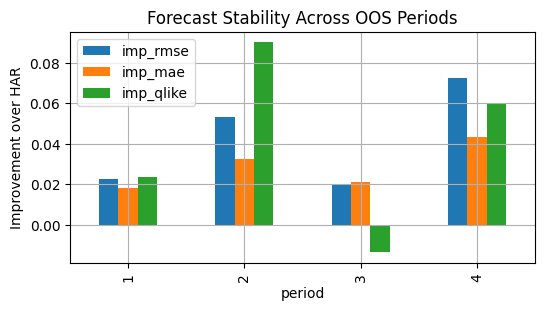

In [14]:
n_periods=4
stab_df = forecast_stability(results, n_periods)

### Out-of-sample analysis

Here we determine the out-of-sample performance of our XGB+HAR and HAR models. We observe that HAR+XGB outperforms HAR across all metrics.

In [15]:
OOS_results = OOS_analysis(feature_df, MAIN_ASSET, selected_features, train_ratio, best_params, HAR_WINDOW)

OOS_metrics = evaluate_forecast(OOS_results["y_true"], OOS_results["y_pred"], OOS_results["y_har"], 
                                model_name="HAR+XGB", bench_name="HAR")

Train period: 2020-01-06 00:00:00 -> 2024-09-17 00:00:00
OOS period:   2024-09-18 00:00:00 -> 2025-11-24 00:00:00


Out-of-sample performance


,RMSE,MAE,QLIKE
HAR,0.5501,0.3428,0.2052
HAR+XGB,0.5101,0.3276,0.1929
Improvement,7.28%,4.44%,6.00%


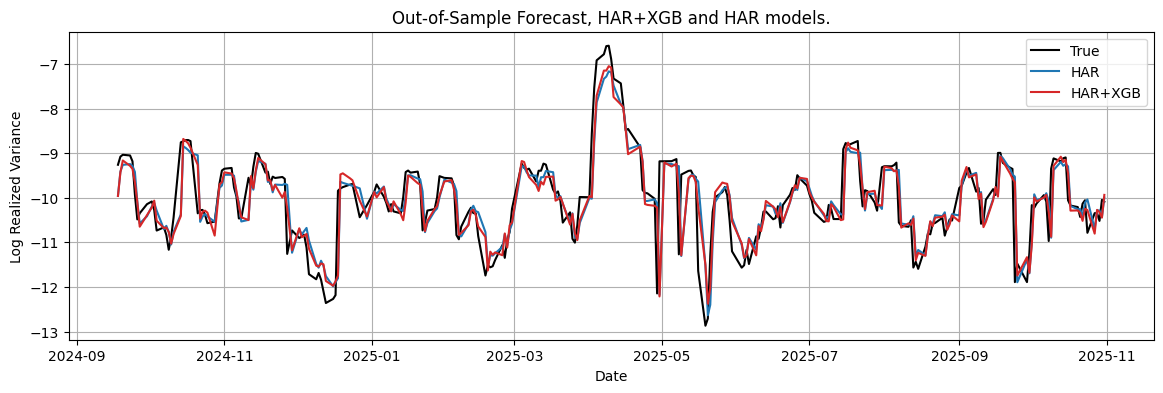

In [16]:
print("Out-of-sample performance")
forecast_metrics(OOS_metrics)

plt.figure(figsize=(14,4))
plt.plot(OOS_results["y_true"], label="True", color='black')
plt.plot(OOS_results["y_har"], label="HAR", color='tab:blue')
plt.plot(OOS_results["y_pred"], label="HAR+XGB", color='tab:red')
plt.title("Out-of-Sample Forecast, HAR+XGB and HAR models.")
plt.ylabel("Log Realized Variance")
plt.xlabel("Date")
plt.legend()
plt.grid()
plt.show()

### Volatility Targeting

We construct a strategy that scales exposure based on predicted volatility, based on the leverage $L_t$:

$$L_t = \frac{\sigma^*}{\widehat{\sigma}_{t,\text{ann}}},$$
Where $\sigma^*$ is the target annualized volatility and $\widehat{\sigma}_{t,\text{ann}}$ is the predicted annualized volatility at time $t$. 
Leverage applied with a one-period lag and we also implement transaction costs to simulate a realistic, implementable strategy.

In [17]:
annualization = 252
target_vol=0.10
min_lev=0.0
max_lev=1.5
tcost_per_turnover=0.0003

In [18]:
vt_df, summary_df = vol_targeting(results, price_df, target_vol, min_lev,
                                  max_lev, tcost_per_turnover, annualization)

### Performance Evaluation

We evaluate strategies using standard financial metrics: annualized return, volatility, Sharpe ratio, and maximum drawdown.

In [19]:
display(
    summary_df.assign(
        **{
            "Annual Return": summary_df["Annual Return"].map("{:.2%}".format),
            "Annual Vol": summary_df["Annual Vol"].map("{:.2%}".format),
            "Sharpe": summary_df["Sharpe"].map("{:.2f}".format),
            "Max Drawdown": summary_df["Max Drawdown"].map("{:.2%}".format),
            "Average Leverage": summary_df["Average Leverage"].map("{:.2f}x".format),
            "Average Turnover": summary_df["Average Turnover"].map("{:.3f}".format)
        }
    )
)

,Strategy,Annual Return,Annual Vol,Sharpe,Max Drawdown,Average Leverage,Average Turnover
0,HAR+XGB Vol Targeted,5.61%,12.18%,0.46,-19.64%,0.90x,0.124
1,HAR Vol Targeted,5.13%,12.09%,0.42,-19.82%,0.89x,0.114
2,Naive Vol Targeted,4.52%,12.17%,0.37,-20.37%,0.90x,0.115
3,Buy & Hold,6.67%,15.52%,0.43,-24.05%,1.00x,0.000


### Results & Conclusion

Volatility targeting reduces portfolio risk, lowering volatility to $12.18\%$ and drawdowns to $-19.64\%$, compared to buy-and-hold annual volatility of $15.52\%$ and drawdown $-24.05\%$. This comes at the cost of lower returns.

The HAR+XGB model achieves the highest Sharpe ratio ($0.46$), outperforming HAR ($0.42$) and the naive benchmark ($0.37$), and slightly exceeding buy-and-hold ($0.43$) after transaction costs.

Without transaction costs, Sharpe improves to $0.54$, with all volatility-targeted strategies outperforming buy-and-hold, highlighting sensitivity to trading costs.

Overall, volatility targeting provides effective risk control, while machine learning delivers modest but consistent improvements in forecasting performance.

### Visualizations

We visualize cumulative performance, portfolio leverage, and forecasted volatility.

The cumulative performance plot shows that strategies behave similarly early on, with HAR+XGB outperforming more consistently in the later period, suggesting improved adaptation to changing market conditions.

Performance differences remain moderate, as volatility targeting standardizes risk across strategies, leading to gradual rather than large return divergences.

The leverage plot shows that all strategies adjust exposure similarly over time, reducing leverage during high-volatility periods and increasing it during calmer periods. This indicates that performance differences are driven primarily by forecast accuracy rather than risk-taking behavior.

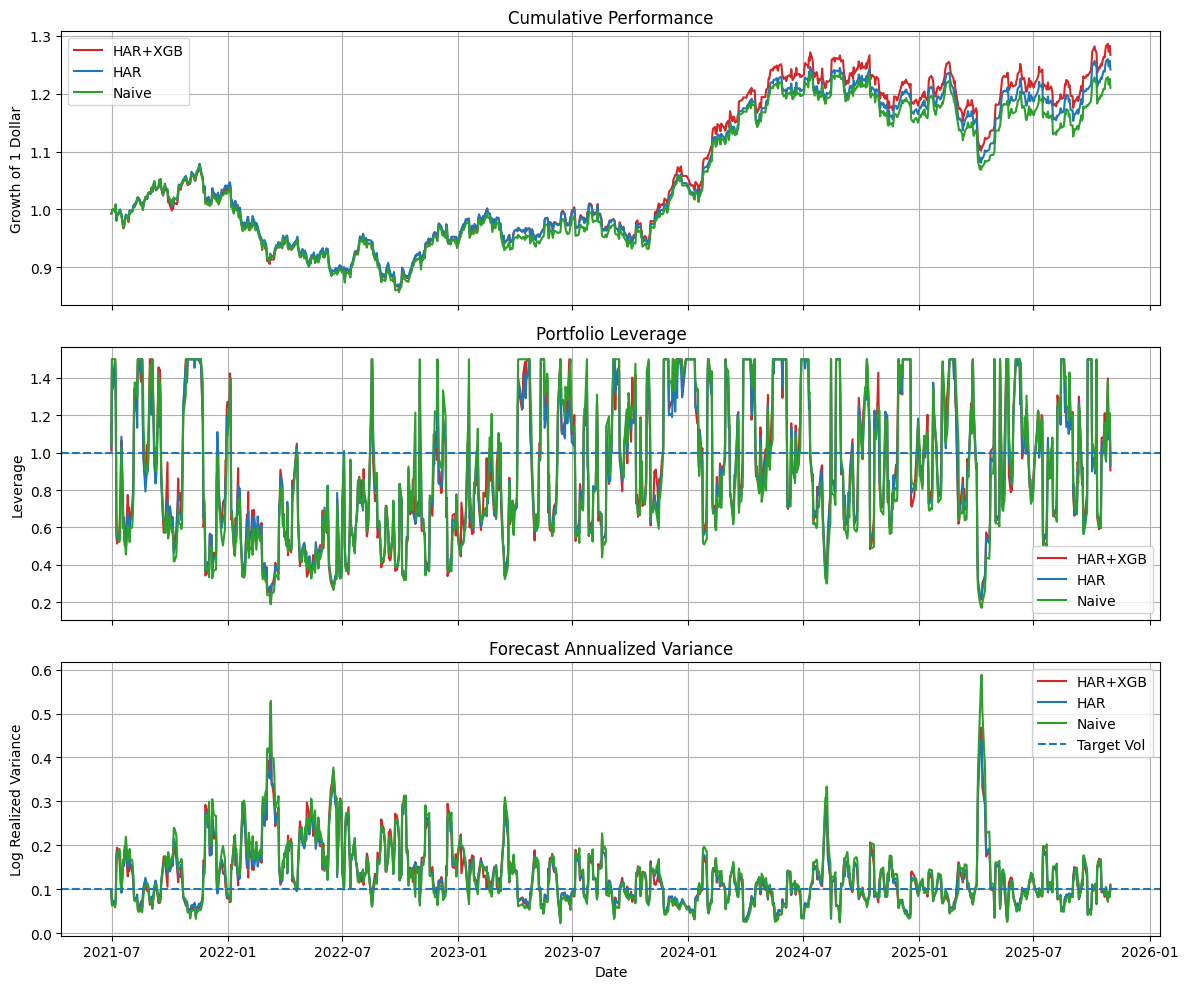

In [20]:
plot_targeting(vt_df, target_vol)